In [2]:
import torch
from torchvision import datasets, transforms,models
from torch.utils.data import DataLoader,random_split,Subset
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np 
import random
from sklearn.model_selection import train_test_split



In [3]:
dataset_path = "dataset/merged_dataset"

train_path = dataset_path + "/train"
test_path = "dataset/test"


In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("DEVICE")
print("=" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [9]:
train_transform = transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ])

test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

In [7]:
full_train_dataset = datasets.ImageFolder(
    train_path,
    transform=None
)

labels = full_train_dataset.targets

train_indices, val_indices = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_dataset = datasets.ImageFolder(
    train_path,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    train_path,
    transform=test_transform
)

train_dataset = Subset(
    train_dataset,
    train_indices
)

val_dataset = Subset(
    val_dataset,
    val_indices
)

test_dataset = datasets.ImageFolder(
    test_path,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [11]:
print("Train:", len(train_dataset))
print('Val:',len(val_dataset))
print("Test:", len(test_dataset))

Train: 2949
Val: 738
Test: 400


In [6]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 150, 150])
Labels shape: torch.Size([32])


In [ ]:
class CNN(nn.Module):

    def __init__(self, num_classes=8):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 18 * 18, 256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [12]:
model = CNN().to(device)

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
model.parameters(),
    lr=0.001
)

In [14]:
best_val_accuracy = 0
patience = 20
counter = 0

for epoch in range(300):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)

    val_accuracy = correct / total

    print(
        f"Epoch [{epoch+1}], "
        f"Train Loss: {train_loss:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        counter = 0

        torch.save(
            model.state_dict(),
            "BEST_MODEL_CustomCNN.pth"
        )

    else:

        counter += 1

        if counter >= patience:

            print("Early stopping!")

            break

model.load_state_dict(
    torch.load(
        "BEST_MODEL_CustomCNN.pth",
        map_location=device
    )
)



Epoch [1], Train Loss: 3.2495, Val Loss: 1.8619, Val Accuracy: 0.3130
Epoch [2], Train Loss: 1.9189, Val Loss: 1.7500, Val Accuracy: 0.2805
Epoch [3], Train Loss: 1.8859, Val Loss: 1.7739, Val Accuracy: 0.4065
Epoch [4], Train Loss: 1.8702, Val Loss: 1.7039, Val Accuracy: 0.4228
Epoch [5], Train Loss: 1.7661, Val Loss: 1.4115, Val Accuracy: 0.4743
Epoch [6], Train Loss: 1.7196, Val Loss: 1.4849, Val Accuracy: 0.4417
Epoch [7], Train Loss: 1.6892, Val Loss: 1.5834, Val Accuracy: 0.4350
Epoch [8], Train Loss: 1.6955, Val Loss: 1.4737, Val Accuracy: 0.3902
Epoch [9], Train Loss: 1.6650, Val Loss: 1.3805, Val Accuracy: 0.4417
Epoch [10], Train Loss: 1.6854, Val Loss: 1.2713, Val Accuracy: 0.4661
Epoch [11], Train Loss: 1.5999, Val Loss: 1.2452, Val Accuracy: 0.4593
Epoch [12], Train Loss: 1.5581, Val Loss: 1.2874, Val Accuracy: 0.4621
Epoch [13], Train Loss: 1.5447, Val Loss: 1.3034, Val Accuracy: 0.4797
Epoch [14], Train Loss: 1.4977, Val Loss: 1.2790, Val Accuracy: 0.5325
Epoch [15], Tra

<All keys matched successfully>

In [17]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_accuracy = (all_labels == all_predictions).mean()

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

Test Accuracy: 92.50%

Classification Report:
              precision    recall  f1-score   support

   ambulance       0.98      0.94      0.96        50
     autobus       0.96      0.88      0.92        50
      kamyun       0.78      0.84      0.81        50
    kamyunet       0.79      0.92      0.85        50
     minibus       1.00      0.92      0.96        50
      savari       0.98      0.98      0.98        50
        taxi       1.00      0.94      0.97        50
       vanet       0.96      0.98      0.97        50

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



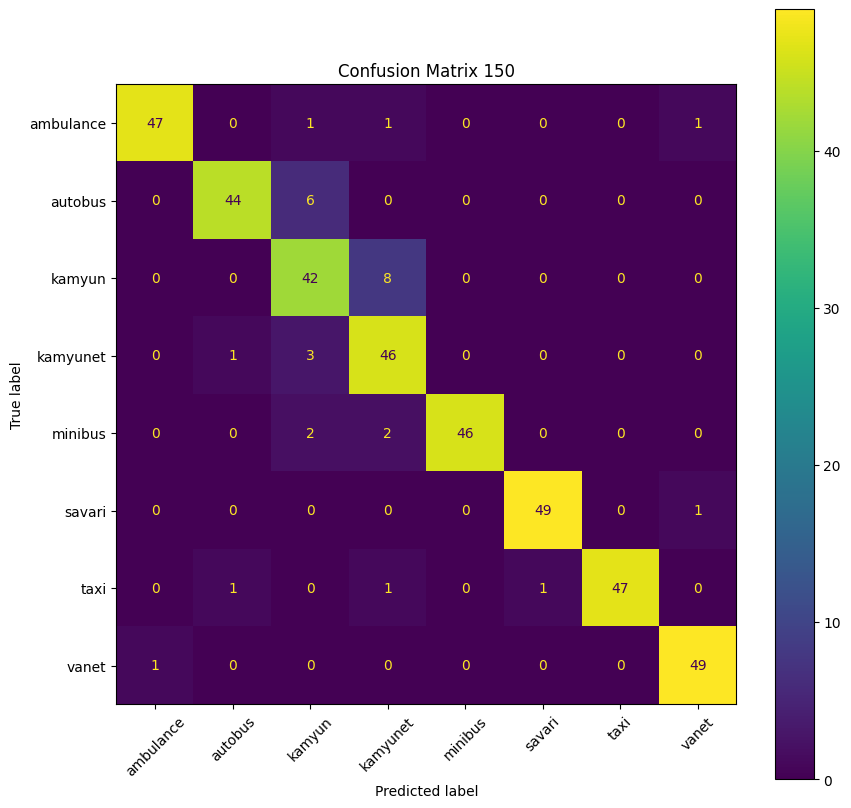

In [18]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(f"Confusion Matrix {images.shape[-1]}")
plt.show()

In [ ]:
augmentation_list = {

    "No Augmentation": transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ToTensor()
    ]),

    "Basic": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.Resize((150, 150)),
        transforms.ToTensor()
    ]),

    "Color": transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),
        transforms.ToTensor()
    ]),

    "Crop": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),
        transforms.ToTensor()
    ]),

    "Full without Color": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full + Basic": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full + Basic + Color": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ])
}




augmentation_count = {

    "No Augmentation": 0,

    "Basic": 2,

    "Color": 1,

    "Crop": 1,

    "Full without Color": 3,

    "Full + Basic": 5,

    "Full + Basic + Color": 6,

    "Full": 4
}



test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])



seeds = [42, 10, 20]

results = []



for augmentation_name, train_transform in augmentation_list.items():

    for seed in seeds:

        print("\n" + "=" * 70)
        print("Augmentation:", augmentation_name)
        print("Seed:", seed)
        print("=" * 70)


        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        

        full_train_dataset = datasets.ImageFolder(
            train_path,
            transform=None
        )

        labels = full_train_dataset.targets

        train_indices, val_indices = train_test_split(
            range(len(full_train_dataset)),
            test_size=0.2,
            stratify=labels,
            random_state=42
        )

        train_dataset = datasets.ImageFolder(
            train_path,
            transform=train_transform
        )

        val_dataset = datasets.ImageFolder(
            train_path,
            transform=test_transform
        )

        train_dataset = Subset(
            train_dataset,
            train_indices
        )

        val_dataset = Subset(
            val_dataset,
            val_indices
        )


        train_loader = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=32,
            shuffle=False
        )

        

        model = models.resnet18(weights="DEFAULT")

        for param in model.parameters():
            param.requires_grad = False

        for param in model.layer4.parameters():
            param.requires_grad = True

        model.fc = nn.Linear(
            model.fc.in_features,
            8
        )


        criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.Adam([
            {
                "params": model.layer4.parameters(),
                "lr": 0.0001
            },
            {
                "params": model.fc.parameters(),
                "lr": 0.001
            }
        ])


        best_val_accuracy = 0
        patience = 20
        counter = 0

        best_model_state = None

        for epoch in range(150):

            model.train()

            total_loss = 0

            for images, labels in train_loader:

                optimizer.zero_grad()

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                loss.backward()

                optimizer.step()

                total_loss += loss.item()

            train_loss = total_loss / len(train_loader)

            

            model.eval()

            correct = 0
            total = 0
            val_total_loss = 0

            with torch.no_grad():

                for images, labels in val_loader:

                    outputs = model(images)

                    loss = criterion(
                        outputs,
                        labels
                    )

                    val_total_loss += loss.item()

                    _, predicted = torch.max(
                        outputs,
                        1
                    )

                    total += labels.size(0)

                    correct += (
                        predicted == labels
                    ).sum().item()

            val_loss = val_total_loss / len(val_loader)

            val_accuracy = correct / total

            print(
                f"Epoch [{epoch+1}], "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val Accuracy: {val_accuracy:.4f}"
            )


            if val_accuracy > best_val_accuracy:

                best_val_accuracy = val_accuracy

                counter = 0

                best_model_state = {
                    k: v.cpu().clone()
                    for k, v in model.state_dict().items()
                }

            else:

                counter += 1

                if counter >= patience:
                    break

       

        results.append({
            "augmentation": augmentation_name,
            "seed": seed,
            "best_val_accuracy": best_val_accuracy,
            "augmentation_count": augmentation_count[
                augmentation_name
            ],
            "model_state": best_model_state
        })

        print(
            f"Best Val Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )




best_result = results[0]

for result in results:

    if result["best_val_accuracy"] > best_result["best_val_accuracy"]:

        best_result = result

    elif (
        result["best_val_accuracy"]
        == best_result["best_val_accuracy"]
    ):

        if (
            result["augmentation_count"]
            > best_result["augmentation_count"]
        ):

            best_result = result




print("\n" + "=" * 70)
print("ALL RESULTS")
print("=" * 70)

for result in results:

    print(
        f"{result['augmentation']:25s} | "
        f"Seed: {result['seed']} | "
        f"Val: {result['best_val_accuracy'] * 100:.2f}% | "
        f"Augmentations: {result['augmentation_count']}"
    )



print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    f"Augmentation: "
    f"{best_result['augmentation']}"
)

print(
    f"Seed: "
    f"{best_result['seed']}"
)

print(
    f"Validation Accuracy: "
    f"{best_result['best_val_accuracy'] * 100:.2f}%"
)

print(
    f"Number of Augmentations: "
    f"{best_result['augmentation_count']}"
)




Augmentation: No Augmentation
Seed: 42
Epoch [1], Train Loss: 0.6177, Val Loss: 0.2876, Val Accuracy: 0.8943
Epoch [2], Train Loss: 0.0975, Val Loss: 0.2254, Val Accuracy: 0.9173
Epoch [3], Train Loss: 0.0280, Val Loss: 0.2274, Val Accuracy: 0.9282
Epoch [4], Train Loss: 0.0124, Val Loss: 0.2235, Val Accuracy: 0.9282
Epoch [5], Train Loss: 0.0054, Val Loss: 0.2104, Val Accuracy: 0.9350
Epoch [6], Train Loss: 0.0045, Val Loss: 0.2632, Val Accuracy: 0.9241
Epoch [7], Train Loss: 0.0033, Val Loss: 0.2366, Val Accuracy: 0.9322
Epoch [8], Train Loss: 0.0030, Val Loss: 0.2315, Val Accuracy: 0.9309
Epoch [9], Train Loss: 0.0055, Val Loss: 0.2803, Val Accuracy: 0.9350
Epoch [10], Train Loss: 0.0040, Val Loss: 0.3001, Val Accuracy: 0.9268
Epoch [11], Train Loss: 0.0060, Val Loss: 0.2799, Val Accuracy: 0.9336
Epoch [12], Train Loss: 0.0257, Val Loss: 0.4133, Val Accuracy: 0.9282
Epoch [13], Train Loss: 0.0070, Val Loss: 0.3505, Val Accuracy: 0.9228
Epoch [14], Train Loss: 0.0102, Val Loss: 0.42

In [5]:
augmentation_list = {

    "No Augmentation": transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ToTensor()
    ]),

    "Basic": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.Resize((150, 150)),
        transforms.ToTensor()
    ]),

    "Color": transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),
        transforms.ToTensor()
    ]),

    "Crop": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),
        transforms.ToTensor()
    ]),

    "Full without Color": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full + Basic": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full + Basic + Color": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ])
}


# ============================================================
# AUGMENTATION COUNT
# ============================================================

augmentation_count = {

    "No Augmentation": 0,

    "Basic": 2,

    "Color": 1,

    "Crop": 1,

    "Full without Color": 3,

    "Full + Basic": 5,

    "Full + Basic + Color": 6,

    "Full": 4
}


# ============================================================
# TEST / VALIDATION TRANSFORM
# ============================================================

test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])


# ============================================================
# SEEDS
# ============================================================

seeds = [42, 10, 20]

results = []


# ============================================================
# TRAINING
# ============================================================

for augmentation_name, train_transform in augmentation_list.items():

    for seed in seeds:

        print("\n" + "=" * 70)
        print("Augmentation:", augmentation_name)
        print("Seed:", seed)
        print("Training: FULL RESNET18")
        print("=" * 70)


        # ====================================================
        # SEED
        # ====================================================

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


        # ====================================================
        # DATASET
        # ====================================================

        full_train_dataset = datasets.ImageFolder(
            train_path,
            transform=None
        )

        labels = full_train_dataset.targets



        train_indices, val_indices = train_test_split(
            range(len(full_train_dataset)),
            test_size=0.2,
            stratify=labels,
            random_state=42
        )


        train_dataset = datasets.ImageFolder(
            train_path,
            transform=train_transform
        )


        val_dataset = datasets.ImageFolder(
            train_path,
            transform=test_transform
        )


        train_dataset = Subset(
            train_dataset,
            train_indices
        )


        val_dataset = Subset(
            val_dataset,
            val_indices
        )


  
        train_loader = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True,
            pin_memory=torch.cuda.is_available(),
            num_workers=0
        )


        val_loader = DataLoader(
            val_dataset,
            batch_size=32,
            shuffle=False,
            pin_memory=torch.cuda.is_available(),
            num_workers=0
        )


        model = models.resnet18(
            weights="DEFAULT"
        )


  
        for param in model.parameters():
            param.requires_grad = True



        model.fc = nn.Linear(
            model.fc.in_features,
            8
        )


        model = model.to(device)


        # ====================================================
        # LOSS
        # ====================================================

        criterion = nn.CrossEntropyLoss()


        # ====================================================
        # OPTIMIZER
        # ====================================================

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.0001
        )


        # ====================================================
        # EARLY STOPPING
        # ====================================================

        best_val_accuracy = 0

        patience = 20

        counter = 0

        best_model_state = None


        # ====================================================
        # EPOCHS
        # ====================================================

        for epoch in range(150):


            # ------------------------------------------------
            # TRAIN
            # ------------------------------------------------

            model.train()

            total_loss = 0


            for images, labels in train_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )


                optimizer.zero_grad()


                outputs = model(images)


                loss = criterion(
                    outputs,
                    labels
                )


                loss.backward()

                optimizer.step()


                total_loss += loss.item()


            train_loss = (
                total_loss /
                len(train_loader)
            )


            # ------------------------------------------------
            # VALIDATION
            # ------------------------------------------------

            model.eval()

            correct = 0

            total = 0

            val_total_loss = 0


            with torch.no_grad():

                for images, labels in val_loader:

                    images = images.to(
                        device,
                        non_blocking=True
                    )

                    labels = labels.to(
                        device,
                        non_blocking=True
                    )


                    outputs = model(images)


                    loss = criterion(
                        outputs,
                        labels
                    )


                    val_total_loss += loss.item()


                    _, predicted = torch.max(
                        outputs,
                        1
                    )


                    total += labels.size(0)


                    correct += (
                        predicted == labels
                    ).sum().item()


            val_loss = (
                val_total_loss /
                len(val_loader)
            )


            val_accuracy = (
                correct /
                total
            )


            print(
                f"Epoch [{epoch + 1}], "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val Accuracy: {val_accuracy:.4f}"
            )


            # =================================================
            # SAVE BEST MODEL
            # =================================================

            if val_accuracy > best_val_accuracy:

                best_val_accuracy = val_accuracy

                counter = 0


                best_model_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }


            else:

                counter += 1


                if counter >= patience:

                    print("Early stopping!")

                    break


        # ====================================================
        # STORE RESULT
        # ====================================================

        results.append({

            "augmentation":
                augmentation_name,

            "seed":
                seed,

            "best_val_accuracy":
                best_val_accuracy,

            "augmentation_count":
                augmentation_count[
                    augmentation_name
                ],

            "model_state":
                best_model_state
        })


        print(
            f"Best Val Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )


# ============================================================
# SELECT BEST MODEL
# ============================================================

best_result = results[0]


for result in results:

    if (
        result["best_val_accuracy"]
        >
        best_result["best_val_accuracy"]
    ):

        best_result = result


    elif (
        result["best_val_accuracy"]
        ==
        best_result["best_val_accuracy"]
    ):

        if (
            result["augmentation_count"]
            >
            best_result["augmentation_count"]
        ):

            best_result = result


# ============================================================
# ALL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("ALL RESULTS - FULL RESNET18")
print("=" * 70)


for result in results:

    print(
        f"{result['augmentation']:25s} | "
        f"Seed: {result['seed']} | "
        f"Val: "
        f"{result['best_val_accuracy'] * 100:.2f}% | "
        f"Augmentations: "
        f"{result['augmentation_count']}"
    )


# ============================================================
# BEST MODEL
# ============================================================

print("\n" + "=" * 70)
print("BEST MODEL - FULL RESNET18")
print("=" * 70)


print(
    f"Augmentation: "
    f"{best_result['augmentation']}"
)


print(
    f"Seed: "
    f"{best_result['seed']}"
)


print(
    f"Validation Accuracy: "
    f"{best_result['best_val_accuracy'] * 100:.2f}%"
)


print(
    f"Number of Augmentations: "
    f"{best_result['augmentation_count']}"
)


# ============================================================
# SAVE BEST MODEL
# ============================================================

model_save_path = "BEST_MODEL_UNCLEAN.pth"


torch.save(
    best_result["model_state"],
    model_save_path
)


print(
    f"\n{model_save_path} "
    "saved successfully."
)


Augmentation: No Augmentation
Seed: 42
Training: FULL RESNET18
Epoch [1], Train Loss: 0.5720, Val Loss: 0.2173, Val Accuracy: 0.9228
Epoch [2], Train Loss: 0.0806, Val Loss: 0.1676, Val Accuracy: 0.9485
Epoch [3], Train Loss: 0.0198, Val Loss: 0.1599, Val Accuracy: 0.9472
Epoch [4], Train Loss: 0.0089, Val Loss: 0.1604, Val Accuracy: 0.9566
Epoch [5], Train Loss: 0.0047, Val Loss: 0.1401, Val Accuracy: 0.9539
Epoch [6], Train Loss: 0.0038, Val Loss: 0.1609, Val Accuracy: 0.9553
Epoch [7], Train Loss: 0.0023, Val Loss: 0.1427, Val Accuracy: 0.9566
Epoch [8], Train Loss: 0.0028, Val Loss: 0.1497, Val Accuracy: 0.9593
Epoch [9], Train Loss: 0.0028, Val Loss: 0.1580, Val Accuracy: 0.9526
Epoch [10], Train Loss: 0.0021, Val Loss: 0.1549, Val Accuracy: 0.9539
Epoch [11], Train Loss: 0.0027, Val Loss: 0.1650, Val Accuracy: 0.9566
Epoch [12], Train Loss: 0.0052, Val Loss: 0.1575, Val Accuracy: 0.9553
Epoch [13], Train Loss: 0.0423, Val Loss: 0.3317, Val Accuracy: 0.8984
Epoch [14], Train Loss

In [8]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    8
)

model.load_state_dict(
    torch.load(
        "BEST_MODEL_UNCLEAN.pth",
        map_location="cpu"
    )
)

model = model.to(device)
model.eval()


all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_accuracy = (all_labels == all_predictions).mean()

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

Test Accuracy: 97.25%

Classification Report:
              precision    recall  f1-score   support

   ambulance       1.00      1.00      1.00        50
     autobus       1.00      0.98      0.99        50
      kamyun       0.90      0.94      0.92        50
    kamyunet       0.92      0.88      0.90        50
     minibus       0.98      0.98      0.98        50
      savari       1.00      1.00      1.00        50
        taxi       1.00      1.00      1.00        50
       vanet       0.98      1.00      0.99        50

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



In [9]:
wrong_predictions = []

start_index = 0

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

        for i in range(len(labels)):

            if predicted[i] != labels[i]:

                wrong_predictions.append({
                    "index": start_index + i,
                    "true_class": test_dataset.classes[
                        labels[i].item()
                    ],
                    "predicted_class": test_dataset.classes[
                        predicted[i].item()
                    ],
                    "confidence": confidence[i].item()
                })

        start_index += len(labels)


print("=" * 80)
print("WRONG PREDICTIONS")
print("=" * 80)

print(
    f"Number of wrong predictions: "
    f"{len(wrong_predictions)}"
)

for item in wrong_predictions:

    print(
        f"Index: {item['index']} | "
        f"True: {item['true_class']} | "
        f"Predicted: {item['predicted_class']} | "
        f"Confidence: {item['confidence'] * 100:.2f}%"
    )

WRONG PREDICTIONS
Number of wrong predictions: 11
Index: 56 | True: autobus | Predicted: minibus | Confidence: 79.42%
Index: 114 | True: kamyun | Predicted: kamyunet | Confidence: 95.03%
Index: 129 | True: kamyun | Predicted: kamyunet | Confidence: 83.44%
Index: 143 | True: kamyun | Predicted: kamyunet | Confidence: 98.67%
Index: 160 | True: kamyunet | Predicted: vanet | Confidence: 31.27%
Index: 171 | True: kamyunet | Predicted: kamyun | Confidence: 99.87%
Index: 181 | True: kamyunet | Predicted: kamyun | Confidence: 97.26%
Index: 182 | True: kamyunet | Predicted: kamyun | Confidence: 91.02%
Index: 190 | True: kamyunet | Predicted: kamyun | Confidence: 87.46%
Index: 199 | True: kamyunet | Predicted: kamyun | Confidence: 99.82%
Index: 230 | True: minibus | Predicted: kamyunet | Confidence: 86.72%
